In [76]:
from sklearn.datasets import load_wine
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
from pickle import dump
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings(action = 'ignore')

In [77]:
wine_data = load_wine()
wine_data_full = pd.DataFrame(wine_data.data,columns = wine_data.feature_names )
wine_data_full.shape

(178, 13)

In [78]:
print(wine_data_full.columns)

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')


In [79]:
wine_data_full['Target'] = wine_data.target

In [80]:
wine_data_full['Target'].value_counts(ascending = True)

Target
2    48
0    59
1    71
Name: count, dtype: int64

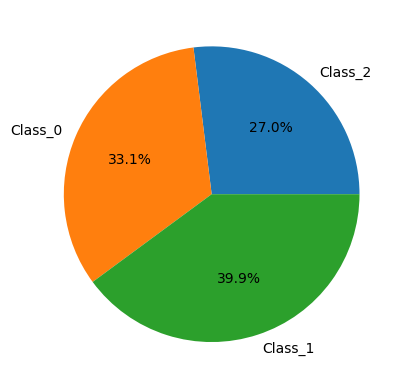

In [93]:
plt.pie(wine_data_full['Target'].value_counts(ascending = True),autopct="%1.1f%%",labels = ['Class_2','Class_0','Class_1'])
plt.show()

In [82]:
wine_data_full.isna().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
Target                          0
dtype: int64

In [66]:
x = wine_data_full.drop('Target',axis = 1)
y = wine_data_full['Target']

In [92]:
Scaled_x = MinMaxScaler()
updated_x = pd.DataFrame(Scaled_x.fit_transform(x),columns = wine_data.feature_names)


In [94]:
x_train,x_test,y_train,y_test=train_test_split(updated_x,y,random_state=12,stratify = y,test_size = 0.20)

In [122]:
from sklearn.model_selection import GridSearchCV

In [129]:
 GSC= GridSearchCV(Neibour_model,param_grid = { 'n_neighbors':range(1,30)})

In [130]:
GSC.fit(updated_x,y)

,estimator,KNeighborsCla...n_neighbors=3)
,param_grid,"{'n_neighbors': range(1, 30)}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,7


In [131]:
GSC.best_params_

{'n_neighbors': 7}

In [132]:
%%time
Neibour_model = KNeighborsClassifier(n_neighbors=7)
Neibour_model.fit(x_train,y_train)

CPU times: total: 0 ns
Wall time: 4.51 ms


,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [133]:
%%time
y_pred_train = Neibour_model.predict(x_train)

CPU times: total: 15.6 ms
Wall time: 31 ms


In [134]:
%%time
y_pred_test = Neibour_model.predict(x_test)

CPU times: total: 0 ns
Wall time: 8.29 ms


In [135]:
from sklearn.metrics import classification_report,confusion_matrix

In [136]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        47
           1       1.00      0.96      0.98        57
           2       0.97      1.00      0.99        38

    accuracy                           0.99       142
   macro avg       0.98      0.99      0.99       142
weighted avg       0.99      0.99      0.99       142



In [137]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.93      0.96        14
           2       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



In [138]:
confusion_matrix(y_train,y_pred_train)

array([[47,  0,  0],
       [ 1, 55,  1],
       [ 0,  0, 38]])

In [139]:
confusion_matrix(y_test,y_pred_test)

array([[12,  0,  0],
       [ 0, 13,  1],
       [ 0,  0, 10]])

In [ ]:
dump(Scaled_x,open())